- 선형 회귀
    - 선형 회귀 모델 개념과 원리
        - 선형 회귀(Linear Regression)는 머신러닝에서 가장 기본적인 지도학습 알고리즘 중 하나로, 입력 변수(X)와 출려 변수(y) 간의 선형 관계를 찾는 데 사용
        - 목적: 주어진 입력 변수로부터 출력 변수를 예측하기 위한 최적의 직선(회귀선)을 찾는 것
        - 회귀선의 방정식
            - y = wX + B
                - w: 기울기(가중치)
                - b: 절편(바이어스)
                - y: 예측값
                - X: 입력값
            - ![Screenshot from 2026-09-23 16-42-19.png](<attachment:Screenshot from 2026-09-23 16-42-19.png>)
        - 간단한 예로 이해하기
        - 문제: 아이스크림 판매량 예측
        - 날씨가 덥거나(기온이 높을 수록) 아이스크림이 더 많이 팔린다고 가정
        - ![Screenshot from 2026-09-23 16-43-42.png](<attachment:Screenshot from 2026-09-23 16-43-42.png>)
        - 목표: 기온이 28도일때, 아이스크림 판매량 예측
        - 직선 찾기:
            - 기온과 판매량 사이의 관계를 직선 y = wX + b 로 표현
            - w: 기울기 (기온이 높아질수록 판매량이 얼마나 증가하는 지)
            - b: 절편 (기온이 0도 일때 예상 판매량)
            - ![Screenshot from 2026-09-23 16-46-21.png](<attachment:Screenshot from 2026-09-23 16-46-21.png>)

            - 학습: 데이터를 기반으로 w와 b를 찾아내는 과정
            - 예측: 학습한 직선을 이용해 기온이 28도일때 판매량 예측
            - 결과: 모델은 학습한 직선을 이용해 28도일때 약 180개를 예측
            - 기본원리
                - 선형 회귀는 데이터와 직선 간의 차이를 최소화 하는 직선을 찾음
                - 데이터와 직선간의 차이는 오차(Error)로 계산하며, 가장 작은 오차를 만들어내는 직선을 찾는 것이 핵심, 이 과정에서 손실 함수(Mean Squared Error)와 최적화 알고리즘(경사 하강법)을 사용
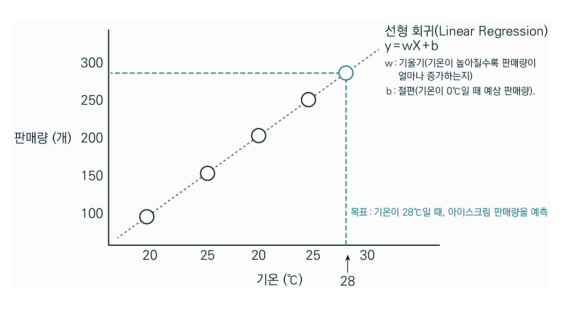
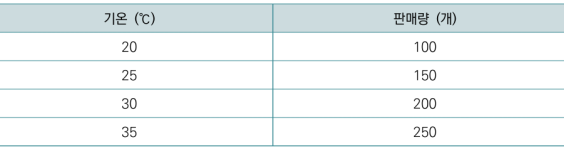
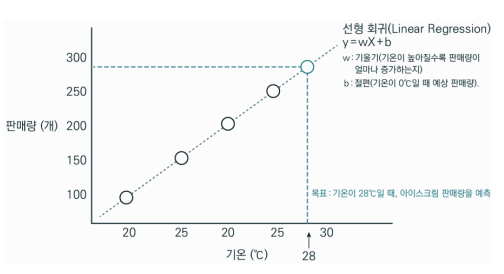

In [1]:
# winequality-white.csv 데이터를 사용해 와인의 화학적 특성을 바탕으로 품질을 예측하는 선형회귀 모델

# 필요한 라이브러리 불러오기
import pandas as pd                                         # 데이터 처리
from sklearn.model_selection import train_test_split        # 데이터 분리
from sklearn.linear_model import LinearRegression           # 선형 회귀 모델
from sklearn.metrics import mean_squared_error, r2_score    # 평가 지표

# 1. 데이터 로드
# winequality-white.csv 파일을 읽어와 데이터 프레임 생성
data = pd.read_csv("./datasets/winequality-white.csv", sep=',')

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,alcohol
0,7.0,0.27,0.36,20.7,45.00,45.0,170.0,1.001,3.00,0.45,6,"R$ 45.512,00"
1,6.3,0.30,0.34,1.6,49.00,14.0,132.0,994.000,3.30,0.49,6,"R$ 45.421,00"
2,8.1,0.28,0.40,6.9,0.05,30.0,97.0,9.951,3.26,0.44,6,"R$ 45.301,00"
3,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"
4,7.2,0.23,0.32,8.5,58.00,47.0,186.0,9.956,3.19,0.40,6,"R$ 45.544,00"


In [2]:
# 2. 입력(X)과 출력(y) 분리
# 독립 변수(X): "quality" 를 제외한 나머지 특성(품질은 예측해야 하는 값)
# 종속 변수(y): "quality" 열 (정답지)
X = data.drop(["quality", "alcohol"], axis=1)   # 입력 데이터(와인의 특성들, y값과 불필요한 열 삭제)
y = data["quality"]                             # 출력 데이터 (와인의 품질 점수)

# 3. 데이터를 학습용과 테스트용으로 나누기
# 학습 데이터: 80%, 테스트 데이터: 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 모델 생성
model = LinearRegression()                # 선형 회귀 모델 생성
model.fit(X_train, y_train)               # 학습 데이터로 모델 학습

# 5. 테스트 데이터로 예측 수행
y_pred = model.predict(X_test)

# 6. 모델 평가
mse = mean_squared_error(y_test, y_pred)  # 평균 제곱 오차 계산
r2 = r2_score(y_test, y_pred)             # 결정 계수 계산

# 결과 출력
print("Mean Squared Error: ", mse)
print("R2 Score: ", r2)

Mean Squared Error:  0.7137778530412319
R2 Score:  0.07836977206253393


- pandas: 데이터를 읽고 처리하고 분석하기 위해 사용
- train_test_split: 데이터를 학습용과 테스트용으로 나누는 함수
- LinearRegression: 선형 회귀 모델 겍체를 생성하는 클래스
- mean_squared_error, r2_score: 모델의 성능을 평가하는 지표를 제공
- pd.read_csv("winequality-white.csv", seq=','): CSV 파일에서 데이터를 읽어와 data라는 데이터 프레임에 저장 데이터는 ','로 구분되어 있음
- 입력(X)과 출력(y) 분리
  - X = data.drop(["quality","alcohol", axis=1]): 품질(quality) 열과 이상치 입력된 alcohol을 제외한 나머지 데이터를 독립 변수로 설정
  - y = data["quality"]: 품질(quality) 열만 종속 변수로 설정
  - train_test_split(X, y, test_size=0.2, random_state=42): 데이터를 학습용(80%)과 테스트용(20%)으로 나눔
    - random_state=42: 결과를 재현하기 위해 시드값 지정
  - model = LinearRegression(): 선형 회귀 모델 객체 생성
  - model.fit(X_train, y_train): 학습 데이터를 사용해 모델을 학습
  - y_pred = model.predict(X_test): 학습된 모델을 사용해 테스트 데이터의 품질을 예측
  - mean_squared_error(y_test, y_pred): 예측 값과 실제 값 간의 평균 제곱 오차를 계산
  - r2_score(y_test, y_pred): 결정 계수(R2)를 계산하여 모델의 설명력을 평가
  - print("Mean Squared Error: ", mse): MSE를 출력하여 모델의 오차 크기 확인
  - print("R2 Score: ", r2): R2값을 출력하여 모델의 성능 확인

Mean Squared Error (MSE):  0.0
Root Mean Squared Error (RMSE):  0.0
R2 Score:  1.0


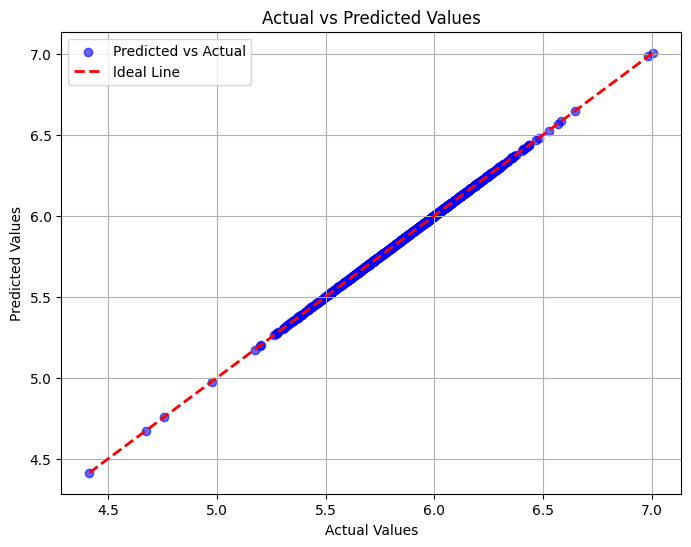

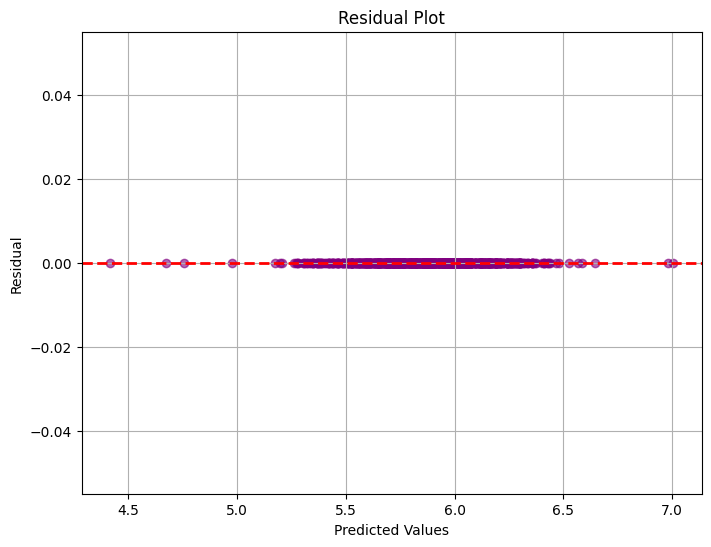

In [8]:
import numpy as np

# 평가 지표 계산
mse = mean_squared_error(y_test, y_pred)   # 평균 제곱 오차
rmse = np.sqrt(mse)                        # 루트 평균 제곱 오차
r2 = r2_score(y_test, y_pred)              # 결정 계수

# 평가 결과 출력
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)
print("R2 Score: ", r2)

import matplotlib.pyplot as plt

# 실제 값 vs 예측 값 비교
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="ldeal Line")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid()
plt.show()

# 잔차(Residual) 시각화
residuals = y_test - y_pred    # 잔차 계산
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color="purple")
plt.axhline(y=0, color='r', linestyle="--", lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid()
plt.show()